In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Ruggedness visualisations

In [ ]:
from functools import partial
import json
import jax.numpy as jnp
import numpy as np
import os
import pandas as pd
from scipy.cluster.hierarchy import linkage, fcluster
import jax
import seaborn as sns
import matplotlib.pyplot as plt
from synbio_morpher.utils.data.data_format_tools.common import load_json_as_dict
from synbio_morpher.utils.results.analytics.naming import get_true_interaction_cols
from synbio_morpher.utils.results.analytics.timeseries import calculate_adaptation
from evoscaper.utils.visualise import make_sort_hue, create_network_inset, make_nx_weights, vis_sampled_histplot
from evoscaper.utils.dataset import embellish_data
from evoscaper.utils.evolution import calculate_ruggedness_from_perturbations

sns.set_style('whitegrid')
jax.config.update('jax_platform_name', 'cpu')

top_dir = os.path.join('..')
top_write_dir = os.path.join('figures', '04_mutations')


# Load

In [27]:
def add_rugg(data: pd.DataFrame, interactions: np.ndarray, objective_cols: list, analytics: dict,
             resimulate_analytics: bool, eps: float, analytics_original=None):

    n_samples = interactions.shape[0]
    n_interactions = interactions.shape[1]
    n_perturbs = n_interactions + resimulate_analytics
    species = data['sample_name'].dropna().unique()
    n_species = len(species)

    for k in objective_cols:
        analytic_perturbed = jnp.array(
            analytics[k]).reshape(n_samples, n_perturbs, -1)
        if resimulate_analytics:
            analytic_perturbed = analytic_perturbed[:, :-1, :]
            analytic_og = analytic_perturbed[:, -1, :]
        else:
            analytic_og = np.array(analytics_original[k][:n_samples])

        # If loaded from previous data where not all analytics were saved
        if analytic_perturbed.shape[-1] != analytic_og.shape[-1]:
            analytic_perturbed = analytic_perturbed[..., -
                                                    analytic_og.shape[-1]:]

        analytic_perturbed = analytic_perturbed[..., -n_species:]
        analytic_og = analytic_og[..., -n_species:]

        ruggedness = jax.vmap(partial(calculate_ruggedness_from_perturbations, eps=eps))(
            analytic_perturbed, analytic_og[:, None, :])

        data[k + ' ruggedness'] = ruggedness.flatten()
    return data


def add_adaptation(d) -> dict | pd.DataFrame:
    if 'adaptation' not in d:
        d['adaptation'] = calculate_adaptation(
            np.array(d['sensitivity']), np.array(d['precision']), alpha=2)
    return d

Load data

In [ ]:
fn_ds0211 = os.path.join(top_dir, 'notebooks', 'data/simulate_circuits/2025_02_11__13_56_51/tabulated_mutation_info.json')
dir_ds0211_rug1 = os.path.join(top_dir, 'notebooks', 'data/07_ruggedness/2025_03_05__15_19_07')
dir_ds0211_rug2 = os.path.join(top_dir, 'notebooks', 'data/07_ruggedness/2025_03_06__22_11_21')

data = pd.read_json(fn_ds0211)
analytics1 = load_json_as_dict(os.path.join(dir_ds0211_rug1, 'analytics.json'))
analytics2 = load_json_as_dict(os.path.join(dir_ds0211_rug2, 'analytics.json'))
config = load_json_as_dict(os.path.join(dir_ds0211_rug1, 'config.json'))
resimulate_analytics = config.get('resimulate_analytics', True)
objective_cols = ['adaptation', 'Log sensitivity', 'Log precision', 'overshoot', 'response_time']

analytics = {}
for k in analytics1:
    if k in analytics2:
        analytics[k] = np.concatenate([analytics1[k], analytics2[k]])
    else: print(k)

analytics = add_adaptation(analytics)
data = add_adaptation(data)

filt = data['sample_name'] == data['sample_name'].dropna().unique()[-1]
cols_e = get_true_interaction_cols(data, 'energies', remove_symmetrical=True)
interactions = data[filt][cols_e].values
n_samples = interactions.shape[0]
species = data['sample_name'].dropna().unique()
analytics_original = {'sensitivity': np.array(data['sensitivity']).reshape(n_samples, len(species)),
                      'precision': np.array(data['precision']).reshape(n_samples, len(species))}
eps_perc = config.get('eps_perc', - 1e-2)
eps = eps_perc * np.abs(interactions).max()

data = add_rugg(data, interactions, objective_cols, analytics, resimulate_analytics, eps)

data['Log ruggedness (adaptation)'] = np.log10(data['adaptation ruggedness'])
data['Log ruggedness (Log sensitivity)'] = np.where(data['Log sensitivity ruggedness'] == 0, -10, np.log10(data['Log sensitivity ruggedness']))

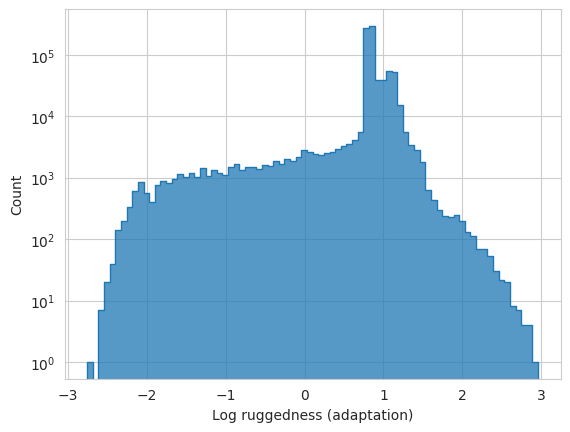

In [ ]:
sns.histplot(data[data['sample_name'] == 'RNA_2'], 
             x='Log ruggedness (adaptation)', bins=80, element='step')
plt.yscale('log')


In [34]:
data.columns

Index(['RMSE', 'fold_change', 'initial_steady_states', 'max_amount',
       'min_amount', 'overshoot', 'precision', 'response_time', 'sensitivity',
       'steady_states', 'Log sensitivity', 'Log precision', 'sample_name',
       'circuit_name', 'mutation_name', 'mutation_num', 'mutation_type',
       'mutation_positions', 'path_to_template_circuit', 'num_interacting',
       'num_self_interacting', 'energies_0-0', 'energies_0-1', 'energies_0-2',
       'energies_1-1', 'energies_1-2', 'energies_2-2',
       'Log sensitivity ruggedness', 'Log precision ruggedness',
       'overshoot ruggedness', 'response_time ruggedness',
       'Log ruggedness (Log sensensitivity)',
       'Log ruggedness (Log sensitivity)', 'eqconstants_0-0',
       'eqconstants_0-1', 'eqconstants_0-2', 'eqconstants_1-1',
       'eqconstants_1-2', 'eqconstants_2-2', 'binding_rates_dissociation_0-0',
       'binding_rates_dissociation_0-1', 'binding_rates_dissociation_0-2',
       'binding_rates_dissociation_1-1', 'bi

# Motifs

In [ ]:
from scipy.cluster.hierarchy import linkage, fcluster
cols_e = get_true_interaction_cols(
    data, 'energies', remove_symmetrical=True)

def plot_cluster(df, row_colors, idxs):
    g = sns.clustermap(interactions, col_cluster=False, row_colors=row_colors)
    n_clusters = 6
    row_linkage = g.dendrogram_row.linkage
    clusters = fcluster(row_linkage, t=n_clusters, criterion='maxclust')

    if row_colors is None:
        plt.close()
        del g

    lut = dict(zip(sorted(pd.Series(clusters).unique()),
                   sns.color_palette('pastel', n_clusters).as_hex()))
    row_colors = pd.Series(clusters).map(lut).to_numpy()

    return row_colors, clusters, n_clusters


filt_adapt = data['adaptation'] > 850
idxs_a_hirugg = data[filt_adapt & (data['Log ruggedness (adaptation)'] > 2)].index
idxs_a_lorugg = data[filt_adapt & (data['Log ruggedness (adaptation)'] < 0.5)].index
row_colors = None
row_colors, clusters, n_clusters = plot_cluster(
    row_colors, idxs_a_lorugg)
row_colors, clusters, n_clusters = plot_cluster(
    row_colors, idxs_a_lorugg)

fig, ax = plt.subplots(figsize=(15, 5))
d_lo = pd.DataFrame()
d_lo['Cluster'] = clusters
d_lo[cols_e + ['adaptation', 'Log ruggedness (adaptation)']] = data[
    cols_e + ['adaptation', 'Log ruggedness (adaptation)']].iloc[idxs_a_lorugg]
pos = np.concatenate([(np.arange(n_clusters) / (n_clusters+1) - 0.2) * 1.3,
                     np.ones(n_clusters) * - 0.1]).reshape(2, -1).T
colors = sns.color_palette('pastel', n_clusters).as_hex()
d_lo = d_lo[d_lo['Cluster'].apply(
    lambda x: np.where(clusters == x, 1, 0).sum() > 2)]
for i, c in enumerate(sorted(d_lo['Cluster'].unique())):
    fake_circuits_cluster = d_lo[d_lo['Cluster']
                                 == c][cols_e].values
    w = np.median(fake_circuits_cluster, axis=0)
    create_network_inset(fig, ax,
                         pos=pos[i],
                         width=0.7, height=0.7, edge_weights=make_nx_weights(w, n_nodes=3,
                                                                             # np.nanmin(data[cols_e]),
                                                                             vmin=-30,
                                                                             vmax=0),  # np.nanmax(data[cols_e]),),
                         node_color=colors[c-1], linewidth=2.5)
ax.set_axis_off()
top_write_dir = os.path.join('figures', '04_mutations')
plt.savefig(os.path.join(top_write_dir, 'motifs_adapt_lorugg.png'),
            dpi=300, bbox_inches='tight', transparent=True)

['2024_11_09_164634',
 '2024_11_27_145142',
 '2024_11_11_135219',
 '2024_11_20_153740',
 '2024_11_21_160955',
 '2024_11_20_224946']